In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
%matplotlib inline

In [9]:
df = pd.read_csv('../data/pro_data/ml_project1_data.csv')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


## Correlación de Pearson y Spearman
Variables analizadas: `Year_Birth`, `Education`, `Marital_Status`, `Income` y todas las variables `Mnt`.

> `Education` y `Marital_Status` se codifican numéricamente (Label Encoding) para poder calcular la correlación.

In [10]:
from sklearn.preprocessing import LabelEncoder

mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
base_cols = ['Year_Birth', 'Education', 'Marital_Status', 'Income']

df_corr = df[base_cols + mnt_cols].copy()
df_corr['Education']      = LabelEncoder().fit_transform(df_corr['Education'].astype(str))
df_corr['Marital_Status'] = LabelEncoder().fit_transform(df_corr['Marital_Status'].astype(str))

pearson  = df_corr.corr(method='pearson')
spearman = df_corr.corr(method='spearman')

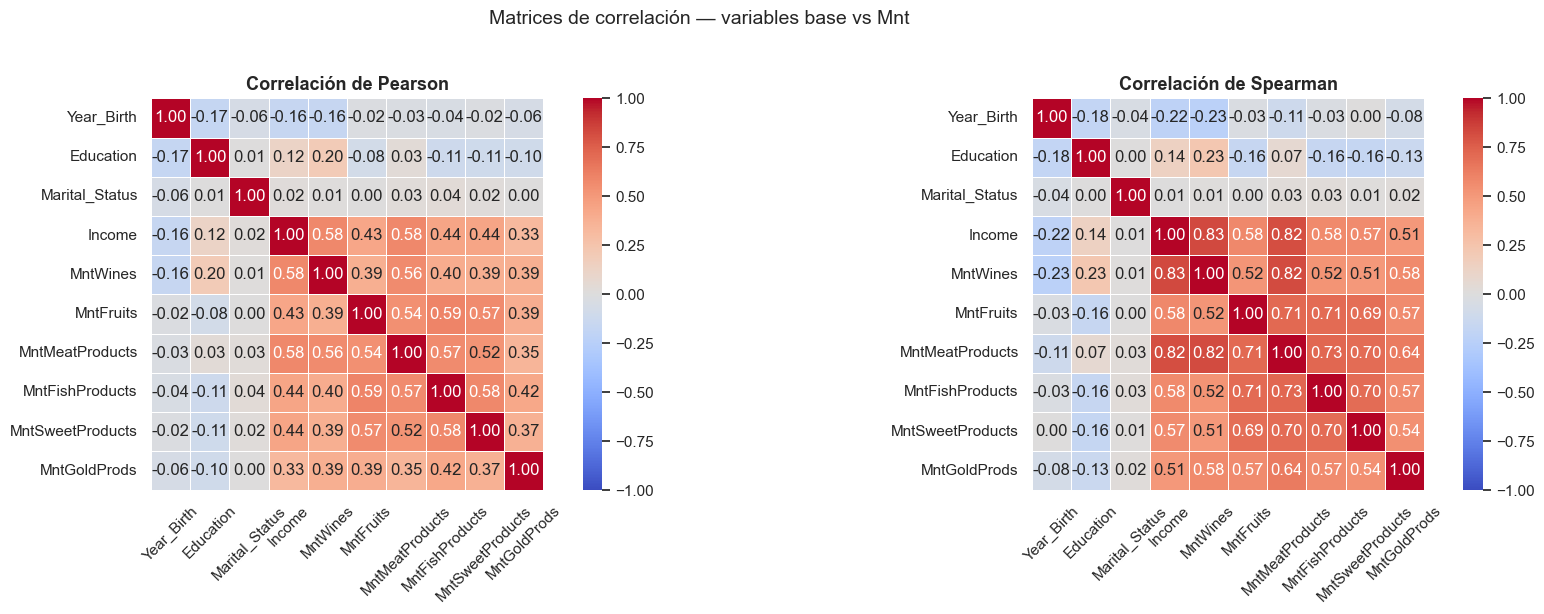

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, matrix, title in zip(axes,
                              [pearson, spearman],
                              ['Correlación de Pearson', 'Correlación de Spearman']):
    sns.heatmap(
        matrix,
        annot=True, fmt='.2f', cmap='coolwarm',
        vmin=-1, vmax=1, square=True,
        linewidths=0.5, ax=ax
    )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Matrices de correlación — variables base vs Mnt', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

He querido observar las correlaciones de pearson y spearman para ser capaz de detectar relaciones lineales y no lineales.


En un primer momento he querido revisar que la variable income pudiera estar relacionada con otros factores socieconomicos que afecten a las ventas. Siendo el income un predictor de estas y no predictor de las ventas.

Viendo este grafico se observa claramente que las variables socieconomicas edad, nacimiento y estatus no tienen una correlacion fuerte con las ventas, mientras que income si disfruta de esta.

## Gráficos: Income vs cada variable Mnt

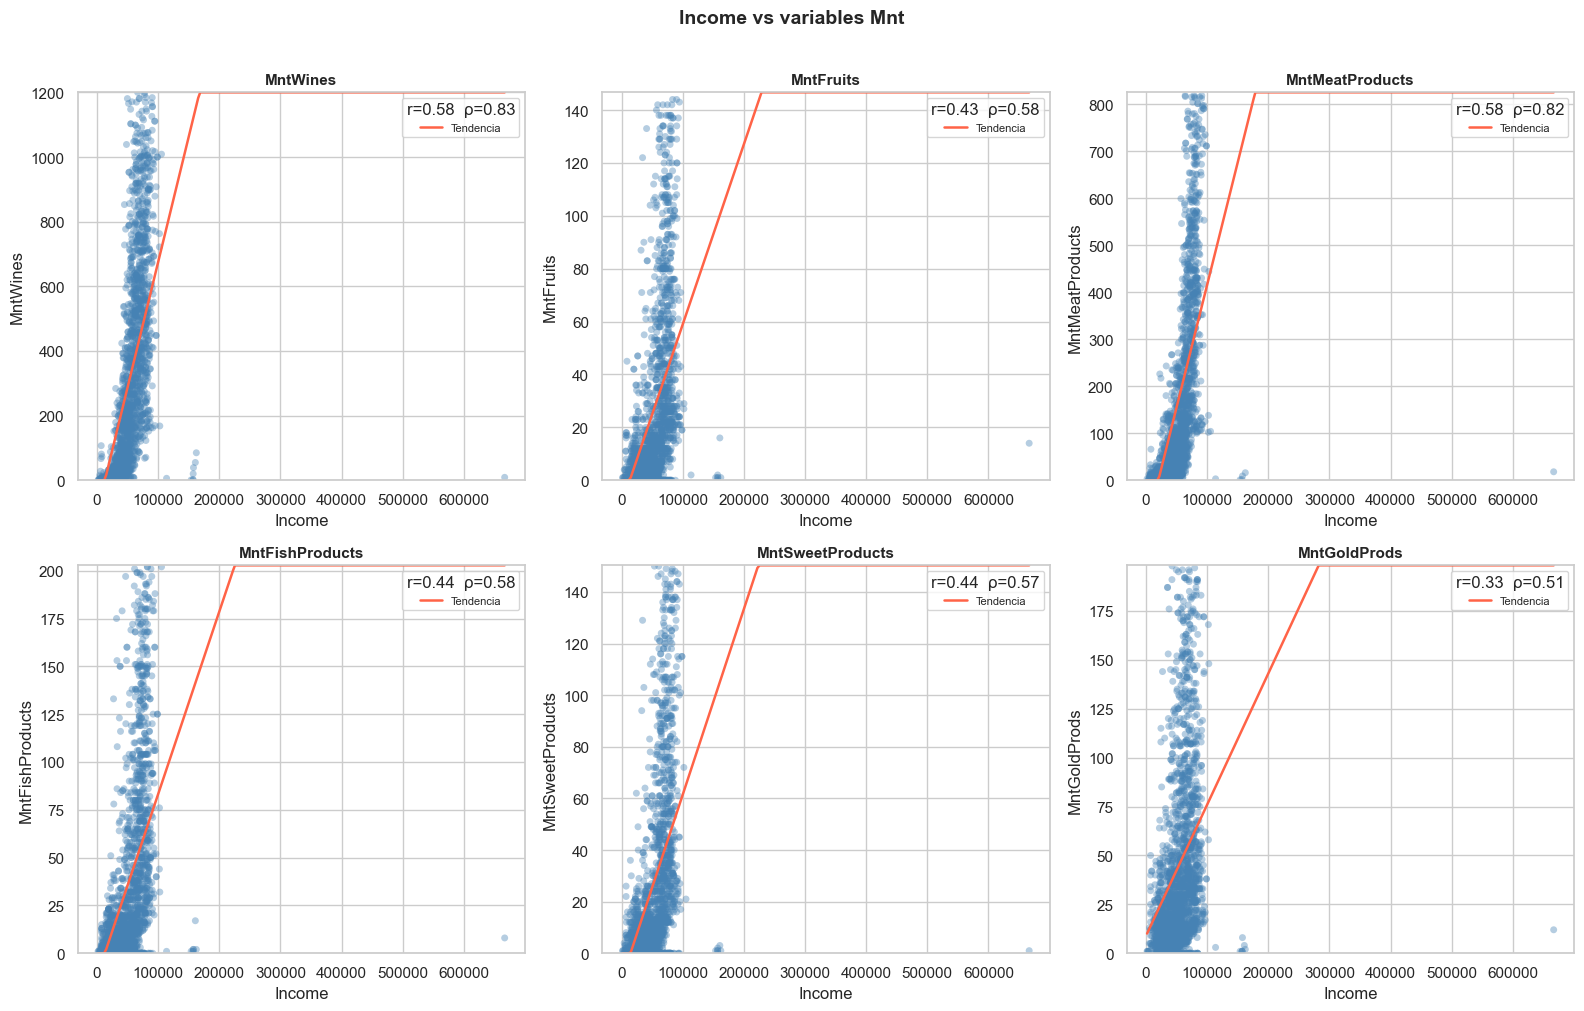

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, mnt_cols):
    mask = df[['Income', col]].dropna()
    y_max = np.percentile(mask[col], 95) * 1.2
    plot_mask = mask[mask[col] <= y_max]

    ax.scatter(plot_mask['Income'], plot_mask[col], alpha=0.4, color='steelblue', edgecolors='none', s=25)

    # línea de tendencia calculada sobre todos los datos (sin recorte)
    m, b = np.polyfit(mask['Income'], mask[col], 1)
    x_line = np.linspace(mask['Income'].min(), mask['Income'].max(), 200)
    y_line = np.clip(m * x_line + b, 0, y_max)
    ax.plot(x_line, y_line, color='tomato', linewidth=1.8, label='Tendencia')

    ax.set_ylim(0, y_max)
    r_p = mask['Income'].corr(mask[col], method='pearson')
    r_s = mask['Income'].corr(mask[col], method='spearman')
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Income')
    ax.set_ylabel(col)
    ax.legend(title=f'r={r_p:.2f}  ρ={r_s:.2f}', fontsize=8)

plt.suptitle('Income vs variables Mnt', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

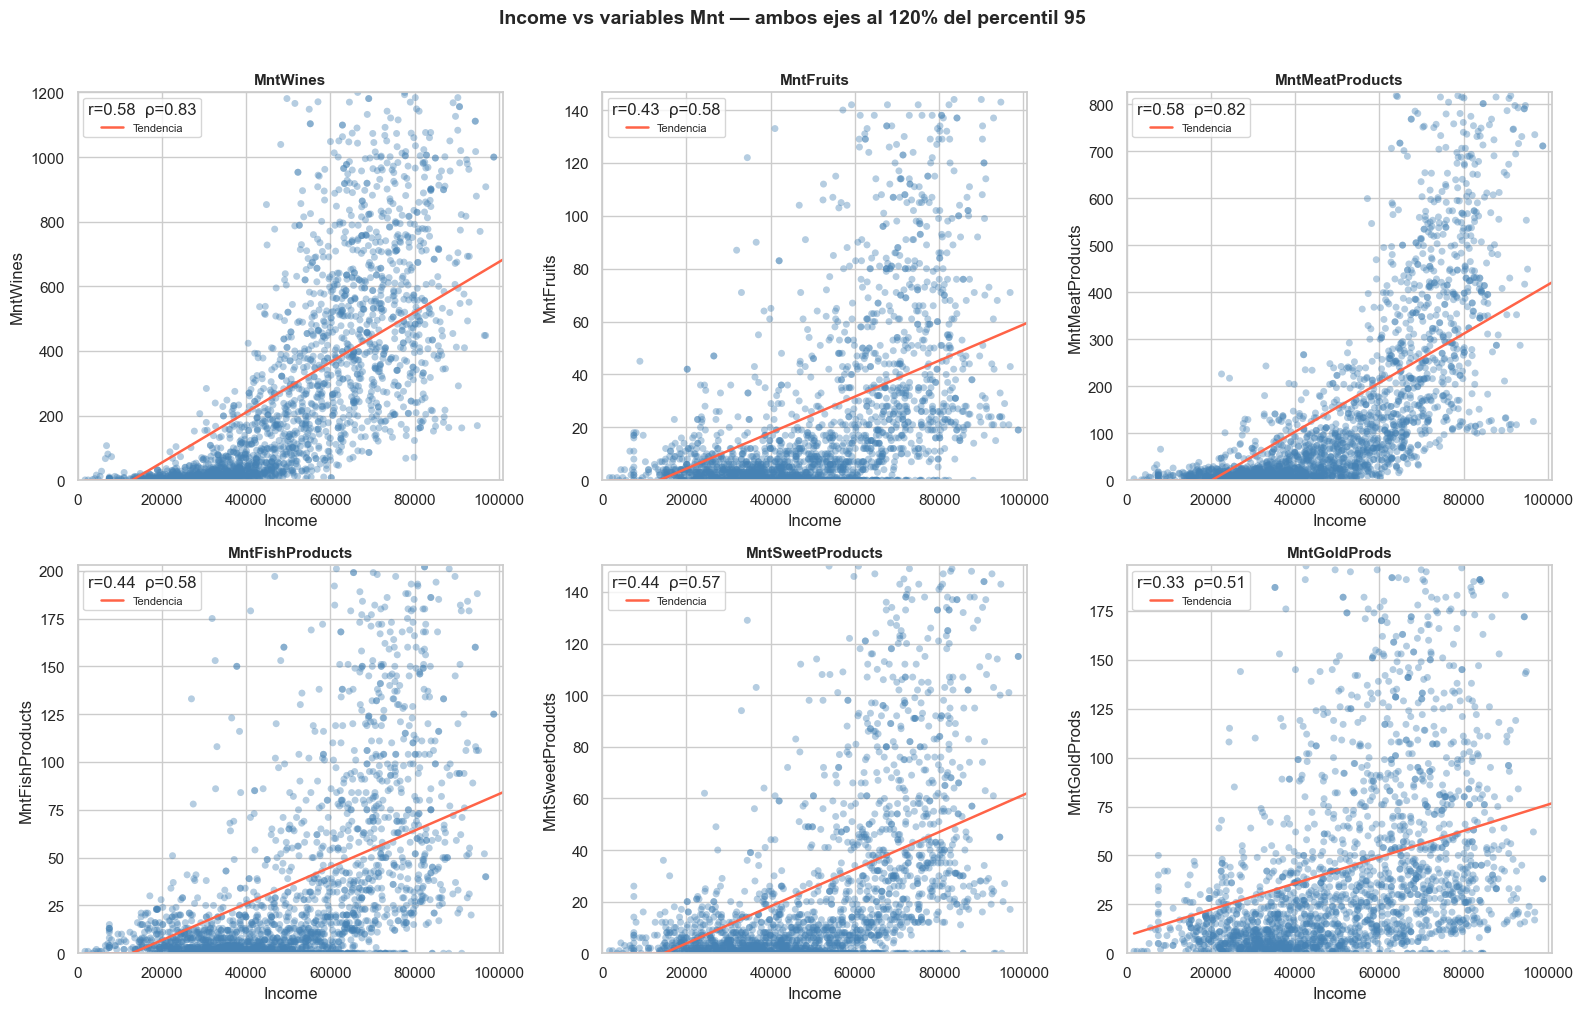

In [13]:
income_max = np.percentile(df['Income'].dropna(), 95) * 1.2

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, mnt_cols):
    mask = df[['Income', col]].dropna()
    y_max = np.percentile(mask[col], 95) * 1.2
    plot_mask = mask[(mask[col] <= y_max) & (mask['Income'] <= income_max)]

    ax.scatter(plot_mask['Income'], plot_mask[col], alpha=0.4, color='steelblue', edgecolors='none', s=25)

    # línea de tendencia calculada sobre todos los datos (sin recorte)
    m, b = np.polyfit(mask['Income'], mask[col], 1)
    x_line = np.linspace(mask['Income'].min(), income_max, 200)
    y_line = np.clip(m * x_line + b, 0, y_max)
    ax.plot(x_line, y_line, color='tomato', linewidth=1.8, label='Tendencia')

    ax.set_xlim(0, income_max)
    ax.set_ylim(0, y_max)
    r_p = mask['Income'].corr(mask[col], method='pearson')
    r_s = mask['Income'].corr(mask[col], method='spearman')
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Income')
    ax.set_ylabel(col)
    ax.legend(title=f'r={r_p:.2f}  ρ={r_s:.2f}', fontsize=8)

plt.suptitle('Income vs variables Mnt — ambos ejes al 120% del percentil 95', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

En un primer momento estos graficos no se apreciaban correctamente, por esto he aplicado un cambio en la escala de estos para que tomen como valor maximo de la escala el 120% del perceptil 95.

Observando este grafico, me atreveria a decir que el precio puede ser un buen predictor, teniendo unas correlaciones claras en los productos wine y meat. En el resto de productos la correlación no es tan fuerte, pero si se puede apreciar que las personas en rangos de salario bajos compran mcuho menos que en rangos de salario mayores. 

Debido a que a partir de ciertos ingresos la correlación directa es menor, porue las personas ya cuentan con un cierto poder adquisitivo y hay un limite racional en lo que pueden gastar. Tiene sentido uqe las relaciones más fuertes las encontremos en spearman.

Tambien parece que si lo observo con un grafico de barras voy a poder apreciar diferencias en el tiquet medio segun rangos salariales.

Quiero observar tambien con boxplots o violin plot la distribución, ya que esta parece indicar que las personas con salarios altos tendran un tiquet minimo  notablemente superior en los perceptiles 80-99 y los usuarios con salarios bajos un tiquet maximo mucho más reducido. en los perceptiles 0-20.


## Ticket medio por rango salarial (gráfico de barras)

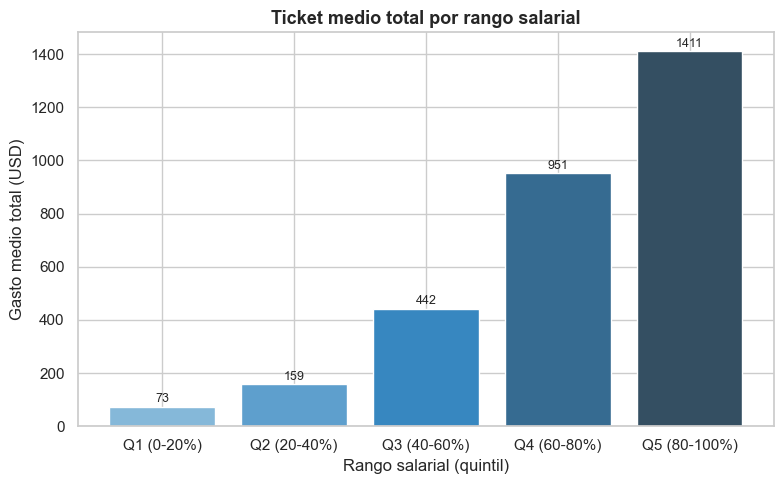

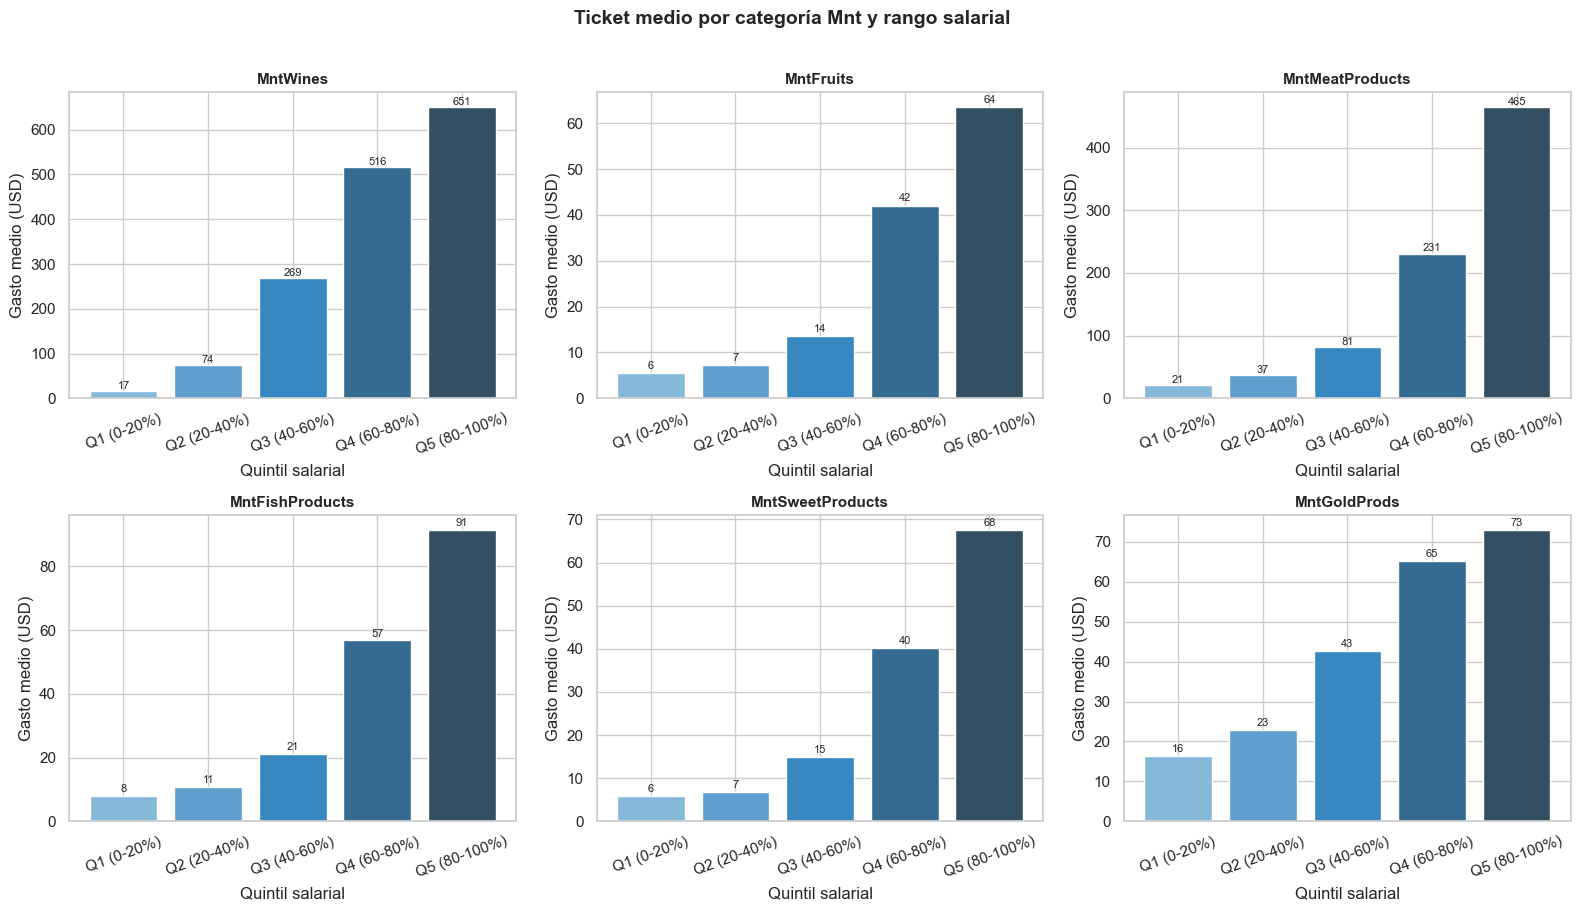

In [14]:
df_plot = df[['Income'] + mnt_cols].dropna().copy()
df_plot['Total_Mnt'] = df_plot[mnt_cols].sum(axis=1)
df_plot['Income_Range'] = pd.qcut(
    df_plot['Income'], q=5,
    labels=['Q1 (0-20%)', 'Q2 (20-40%)', 'Q3 (40-60%)', 'Q4 (60-80%)', 'Q5 (80-100%)']
)

palette = sns.color_palette('Blues_d', n_colors=5)

# --- Ticket medio total ---
fig, ax = plt.subplots(figsize=(8, 5))
mean_total = df_plot.groupby('Income_Range', observed=True)['Total_Mnt'].mean()
bars = ax.bar(mean_total.index, mean_total.values, color=palette)
for bar, val in zip(bars, mean_total.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 5, f'{val:.0f}', ha='center', va='bottom', fontsize=9)
ax.set_title('Ticket medio total por rango salarial', fontsize=13, fontweight='bold')
ax.set_xlabel('Rango salarial (quintil)')
ax.set_ylabel('Gasto medio total (USD)')
plt.tight_layout()
plt.show()

# --- Ticket medio por categoría Mnt ---
mean_by_cat = df_plot.groupby('Income_Range', observed=True)[mnt_cols].mean()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, col in zip(axes, mnt_cols):
    bars = ax.bar(mean_by_cat.index, mean_by_cat[col], color=palette)
    for bar, val in zip(bars, mean_by_cat[col]):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5, f'{val:.0f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('Quintil salarial')
    ax.set_ylabel('Gasto medio (USD)')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Ticket medio por categoría Mnt y rango salarial', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Distribución del gasto por rango salarial (Violin plot)\n\nSe marcan los percentiles **p20** (techo del grupo de salario bajo) y **p80** (suelo del grupo de salario alto) para visualizar el contraste entre ambos extremos.

C:\Users\Caju\AppData\Local\Temp\ipykernel_21092\3244766067.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


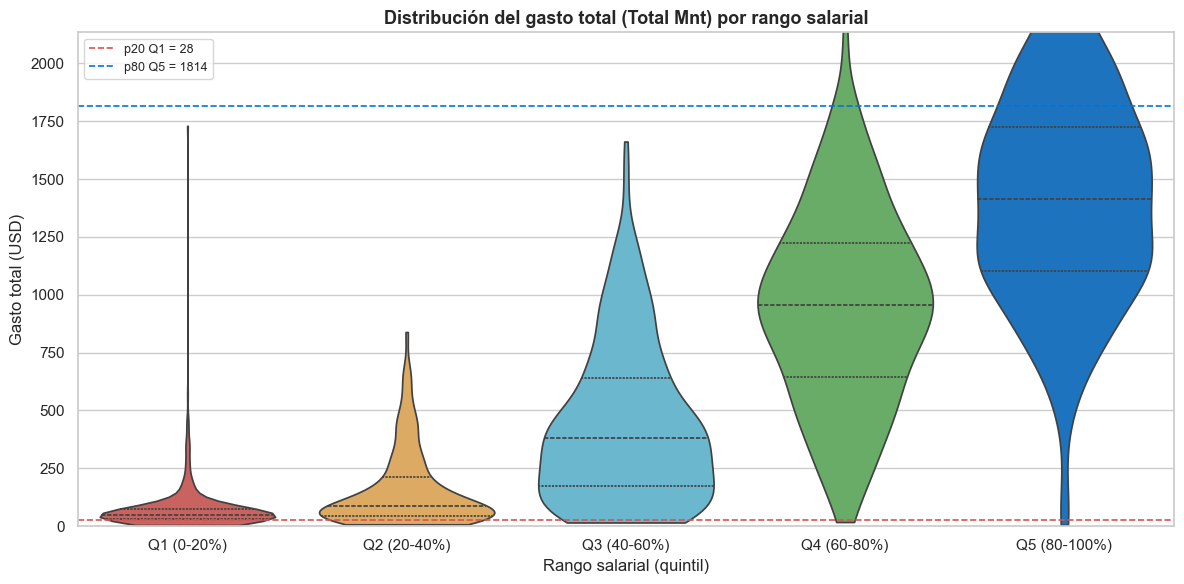

C:\Users\Caju\AppData\Local\Temp\ipykernel_21092\3244766067.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Caju\AppData\Local\Temp\ipykernel_21092\3244766067.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Caju\AppData\Local\Temp\ipykernel_21092\3244766067.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Caju\AppData\Local\Temp\ipykernel_21092\3244766067.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable 

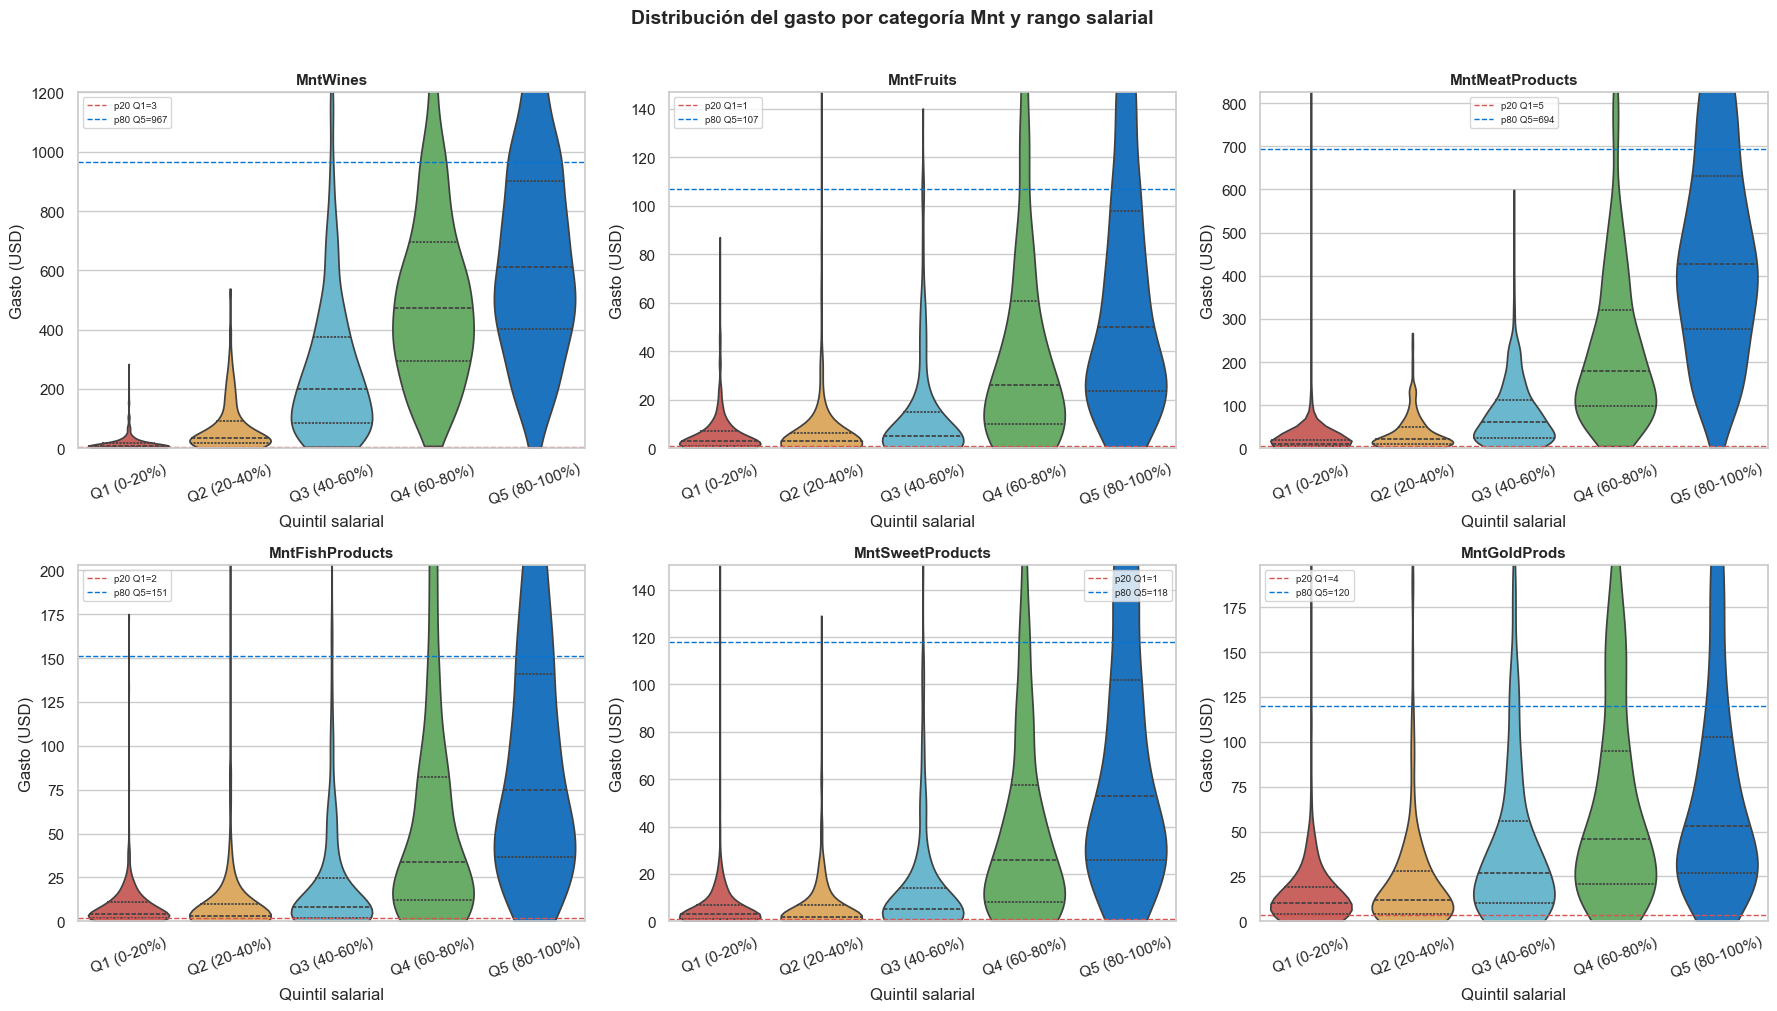

In [15]:
quintil_palette = {
    'Q1 (0-20%)':   '#d9534f',
    'Q2 (20-40%)':  '#f0ad4e',
    'Q3 (40-60%)':  '#5bc0de',
    'Q4 (60-80%)':  '#5cb85c',
    'Q5 (80-100%)': '#0275d8'
}
y_max_violin = np.percentile(df_plot['Total_Mnt'], 95) * 1.2

# --- Violin plot: Total_Mnt por quintil salarial ---
fig, ax = plt.subplots(figsize=(12, 6))
sns.violinplot(
    data=df_plot, x='Income_Range', y='Total_Mnt',
    palette=quintil_palette, inner='quartile', cut=0, ax=ax
)
ax.set_ylim(0, y_max_violin)
ax.set_title('Distribución del gasto total (Total Mnt) por rango salarial', fontsize=13, fontweight='bold')
ax.set_xlabel('Rango salarial (quintil)')
ax.set_ylabel('Gasto total (USD)')

# Anotar p20 del Q1 y p80 del Q5
q1_p20 = np.percentile(df_plot[df_plot['Income_Range'] == 'Q1 (0-20%)']['Total_Mnt'], 20)
q5_p80 = np.percentile(df_plot[df_plot['Income_Range'] == 'Q5 (80-100%)']['Total_Mnt'], 80)

ax.axhline(q1_p20, color='#d9534f', linestyle='--', linewidth=1.2, label=f'p20 Q1 = {q1_p20:.0f}')
ax.axhline(q5_p80, color='#0275d8', linestyle='--', linewidth=1.2, label=f'p80 Q5 = {q5_p80:.0f}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# --- Violin plots por cada variable Mnt ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, col in zip(axes, mnt_cols):
    y_max_col = np.percentile(df_plot[col], 95) * 1.2
    sns.violinplot(
        data=df_plot, x='Income_Range', y=col,
        palette=quintil_palette, inner='quartile', cut=0, ax=ax
    )
    ax.set_ylim(0, y_max_col)

    q1_p20_col = np.percentile(df_plot[df_plot['Income_Range'] == 'Q1 (0-20%)'][col], 20)
    q5_p80_col = np.percentile(df_plot[df_plot['Income_Range'] == 'Q5 (80-100%)'][col], 80)
    ax.axhline(q1_p20_col, color='#d9534f', linestyle='--', linewidth=1.0, label=f'p20 Q1={q1_p20_col:.0f}')
    ax.axhline(q5_p80_col, color='#0275d8', linestyle='--', linewidth=1.0, label=f'p80 Q5={q5_p80_col:.0f}')

    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('Quintil salarial')
    ax.set_ylabel('Gasto (USD)')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(fontsize=7)

plt.suptitle('Distribución del gasto por categoría Mnt y rango salarial', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

¿Porque violin plots? porque son menos sensibles a outliers a la hora de visualizar? La media podria haberse visto muy distrosionada.

En este ultimo grafico, puedo ver claramente que las distribuciones variab en base al salario en todas las categorias de producto, por lo que puedo afirmar que income va a ser una variable util para predecir las ventas en toda la linea de productos.

¿Como aplicaria esto a negocio?

Me sentaria a ver con Marketing el CAC de los diferentes perfiles de cliente para optimizar la inversión. Ya que el LTV de los diferentes segmentos de income y producto es claramente diferente. Y puede ser la diferencia para que la publicidad dirigida a ciertos segmentos sea rentable o no.

## Tabla resumen: correlación de Income con cada variable Mnt

In [16]:
from IPython.display import display

rows = []
for col in mnt_cols:
    subset = df[['Income', col]].dropna()
    rows.append({
        'Variable Mnt': col,
        'Pearson (r)':  round(subset['Income'].corr(subset[col], method='pearson'),  4),
        'Spearman (ρ)': round(subset['Income'].corr(subset[col], method='spearman'), 4)
    })

resumen = pd.DataFrame(rows).set_index('Variable Mnt')
display(
    resumen.style
        .background_gradient(cmap='RdYlGn', subset=['Pearson (r)', 'Spearman (ρ)'], vmin=-1, vmax=1)
        .format('{:.4f}')
        .set_caption('Correlación de Income con variables Mnt')
)

,Pearson (r),Spearman (ρ)
Variable Mnt,,
MntWines,0.5786,0.8301
MntFruits,0.4308,0.5824
MntMeatProducts,0.5846,0.8168
MntFishProducts,0.4389,0.5774
MntSweetProducts,0.4407,0.5671
MntGoldProds,0.3259,0.5056
